In [2]:
import gymnasium as gym

# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="human")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)
for _ in range(1000):
    # this is where you would insert your policy
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

env.close()

## Maze Debugging

In [7]:
from pyamaze import maze
import pandas as pd
import tkinter as tk
import matplotlib.pyplot as plt

In [ ]:

tk.Tk.state = lambda self, s=None: self.wm_state('normal' if s == 'zoomed' else s)
def generate_df_maze(rows=20, cols=20, lp=80):
    # Create a Pyamaze maze
    m = maze(rows, cols)
    m.CreateMaze(loopPercent=lp)  # No loops to match a grid-like maze

    # List to store cell data
    maze_data = []
    for y in range(1, rows + 1):
        for x in range(1, cols + 1):
            cell = (x, y)
            cell_walls = m.maze_map[cell]  # Get wall info for each cell

            E = 1 if cell_walls['E'] else 0
            W = 1 if cell_walls['W'] else 0
            N = 1 if cell_walls['N'] else 0
            S = 1 if cell_walls['S'] else 0

            maze_data.append([f"({x},{y})", E, W, N, S])

    df = pd.DataFrame(maze_data, columns=["  cell  ", "E", "W", "N", "S"])
    if '  cell  ' in df.columns:
        df[['row', 'col']] = (
            df['  cell  '].astype(str)
            .str.replace(r'[()]', '', regex=True)
            .str.split(',', expand=True)
            .astype(int)
        )
    return df, m

In [3]:
# df_maze, m = generate_df_maze(
#             5,
#             5,
#             40
#         )
df_maze = pd.read_csv("data/rl_maze.csv")

In [14]:
m.run()

In [37]:
df_maze.iloc[44]

  cell      (5,5)
E               1
W               0
N               1
S               1
row             5
col             5
Name: 44, dtype: object

In [4]:
import networkx as nx
def _build_graph(df_maze):
        G = nx.Graph()
        for _, row in df_maze.iterrows():
            r, c = int(row['row']), int(row['col'])
            G.add_node((r, c))
            if row['E'] == 1:
                G.add_edge((r, c), (r, c+1))
            if row['W'] == 1:
                G.add_edge((r, c), (r, c - 1))
            if row['N'] == 1:
                G.add_edge((r, c), (r - 1, c))
            if row['S'] == 1:
                G.add_edge((r, c), (r + 1,c))
        return G

In [5]:
G = _build_graph(df_maze)

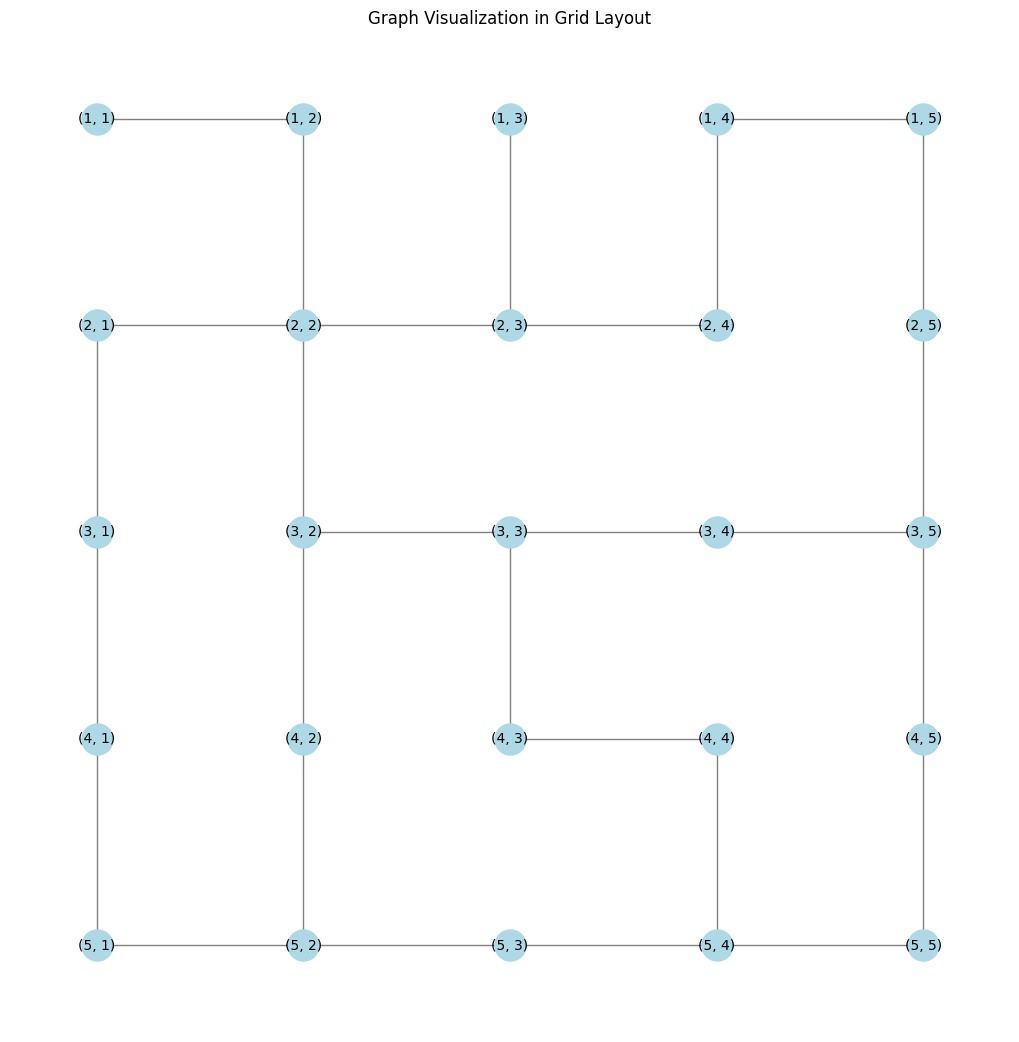

In [8]:
# Arrange nodes in a grid layout
pos = {(row['col'], row['row']): (row['row'], -row['col']) for _, row in df_maze.iterrows()}

# Draw the graph
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, edge_color='gray')
plt.title("Graph Visualization in Grid Layout")
plt.show()

In [34]:
# Print the edges of the center node
max_row = df_maze['row'].max()
max_col = df_maze['col'].max()
center_row = max_row // 2
center_col = max_col // 2
center_node = (center_col, center_row)
edges = G.edges(center_node)
print(f"Edges of the center node {center_node}: {list(edges)}")

Edges of the center node (np.int64(5), np.int64(5)): [((np.int64(5), np.int64(5)), (4, 5)), ((np.int64(5), np.int64(5)), (5, 6)), ((np.int64(5), np.int64(5)), (6, 5))]


In [18]:
df_maze.to_csv("data/rl_maze.csv", index=False)

## Plotting the Training Log

Single Agent Working

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_results = pd.read_csv("runs/sarsa/3e496bd0/train_log.txt")

df_results.head()

,Episode,Total Reward,Epsilon
0,1,-21793.0,0.199
1,2,-23093.0,0.198
2,3,-22853.0,0.197
3,4,-21843.0,0.196
4,5,-17466.0,0.195


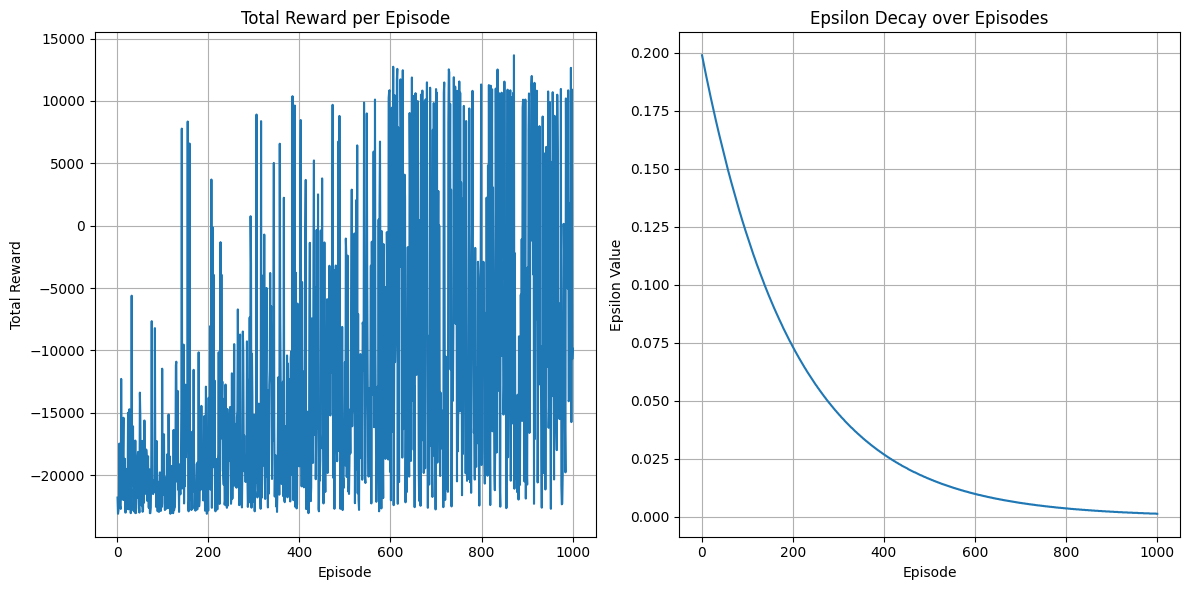

In [5]:
plt.figure(figsize=(12, 6))

# Plot 1: Total Reward over episodes
plt.subplot(1, 2, 1)
plt.plot(df_results['Episode'], df_results[' Total Reward'])
plt.title('Total Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)

# Plot 2: Epsilon over episodes
plt.subplot(1, 2, 2)
plt.plot(df_results['Episode'], df_results[' Epsilon'])
plt.title('Epsilon Decay over Episodes')
plt.xlabel('Episode')
plt.ylabel('Epsilon Value')
plt.grid(True)

plt.tight_layout()
plt.show()

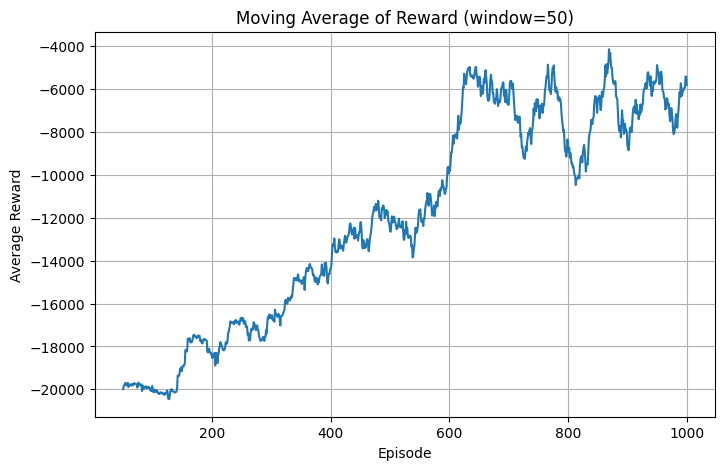

In [6]:
window_size = 50  # Adjust this for smoother or more responsive averaging
moving_avg = df_results[' Total Reward'].rolling(window=window_size).mean()

plt.figure(figsize=(8, 5))
plt.plot(df_results['Episode'][window_size-1:], moving_avg[window_size-1:])
plt.title(f'Moving Average of Reward (window={window_size})')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.grid(True)
plt.show()

## Visualizing Policy

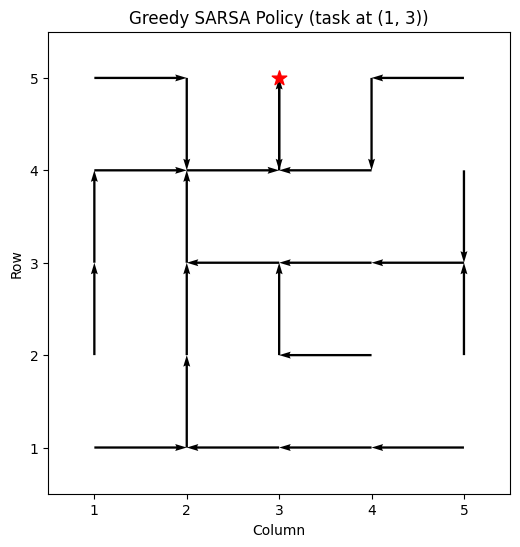

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1) LOAD SAVED Q‑TABLE -------------------
q_policy_path = 'runs/sarsa/train/c6f70031/policy.pkl'         # path to your pickled Q dict
with open(q_policy_path, 'rb') as f:
    Q = pickle.load(f)                  # Q: dict[state] -> np.array of action‑values

# --- 2) VISUALIZATION PARAMETERS -------------
task = (1, 3)                            # fixed task location
n_rows, n_cols = 5, 5                  # dimensions of your grid
action_map = {
    0: (-1,  0),   # up
    1: ( 0,  1),   # right
    2: ( 1,  0),   # down
    3: ( 0, -1),   # left
    # extend for any extra actions you have
}

# --- 3) BUILD VECTOR FIELD + COLOR CODES ----
X, Y, U, V, colors = [], [], [], [], []
for i in range(1,n_rows+1):
    for j in range(1,n_cols+1):
        state = ((i, j), task)
        if state in Q:
            qvals = Q[state]
            col = 'black'           # seen in training
        else:
            qvals = np.zeros(len(action_map))
            col = 'red'             # never visited during training

        best_action = int(np.argmax(qvals))
        dx, dy = action_map[best_action]

        # quiver uses (x, y) = (col, row), flipping row so (0,0) is bottom‑left
        X.append(j)
        Y.append(n_rows - i+1)   # flip row so (0,0) is at bottom‑left
        U.append(dy)
        V.append(-dx)
        colors.append(col)

# --- 4) PLOT WITH QUIVER -----------------------
plt.figure(figsize=(6,6))
plt.quiver(
    X, Y, U, V,
    angles='xy', scale_units='xy', scale=1,
    width=0.005, color=colors
)

# mark the task
tx, ty = task
plt.scatter([ty], [n_rows + 1 - tx], color='red', s=120, marker='*', label='Task')

# add legend for visited vs. unseen
visited_patch = mpatches.Patch(color='black', label='Visited in training')
unseen_patch  = mpatches.Patch(color='red',   label='Unseen state')
# plt.legend(handles=[visited_patch, unseen_patch], loc='upper right')

plt.xlim(0.5, n_cols + 0.5)
plt.ylim(0.5, n_rows + 0.5)
plt.gca().set_aspect('equal')
plt.title(f"Greedy SARSA Policy (task at {task})")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()


In [12]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1) LOAD SAVED Q‑TABLE -------------------
q_policy_path = 'runs/sarsa/8446b493/policy.pkl'
with open(q_policy_path, 'rb') as f:
    Q = pickle.load(f)  